In [177]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import argparse
import glob
import os
from pathlib import Path

In [201]:
def parse_improvement_file(filename):
    """Parse improvement file and return (times, objectives) arrays."""
    times = []
    objectives = []
    
    try:
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                # Skip comments and empty lines
                if not line or line.startswith('#'):
                    continue
                
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        time = float(parts[0])
                        obj = float(parts[1])
                        times.append(time)
                        objectives.append(obj)
                    except ValueError:
                        continue
    except FileNotFoundError:
        print(f"Warning: File {filename} not found, skipping...")
        return None, None
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None, None
    
    if len(times) == 0:
        print(f"Warning: No data found in {filename}")
        return None, None
    
    return np.array(times), np.array(objectives)

In [257]:
instance_name = "tai175e05"

pdbo_file = f"./results/pdbo/{instance_name}.txt"
rots_file = f"./results/baseline/{instance_name}_rots_improvements.txt"
bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"


pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
rots_time, rots_obj = parse_improvement_file(rots_file)
bma_time, bma_obj = parse_improvement_file(bma_file)

In [258]:
yscale_limit = 2.5
xscale_limit = 900

# choose the minimum objective value for time within xscale_limit
pdbo_mask = pdbo_time <= xscale_limit
rots_mask = rots_time <= xscale_limit
bma_mask = bma_time <= xscale_limit
# pdbo_obj = pdbo_obj / base_obj
# rots_obj = rots_obj / base_obj
# bma_obj = bma_obj / base_obj

pdbo_obj = pdbo_obj[pdbo_mask]
rots_obj = rots_obj[rots_mask]
bma_obj = bma_obj[bma_mask]

base_obj = min(bma_obj)

pdbo_obj = np.minimum(pdbo_obj / base_obj, yscale_limit)
rots_obj = np.minimum(rots_obj / base_obj, yscale_limit)
bma_obj = np.minimum(bma_obj / base_obj, yscale_limit)

pdbo_time = pdbo_time[pdbo_mask]
rots_time = rots_time[rots_mask]
bma_time = bma_time[bma_mask]

In [259]:
# files = [pdbo_file, rots_file, bma_file]
file_dict = {"pdbo": pdbo_file, "rots": rots_file, "bma": bma_file}

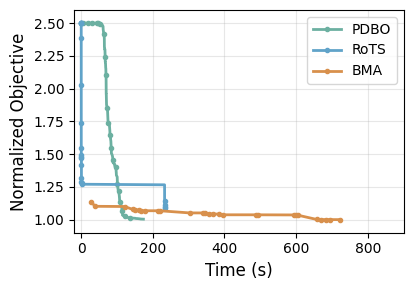

In [260]:
plt.figure(figsize=(4, 3))
colors = ["#6cb0a1", "#60a3c9", "#d8904c"]
# linestyles = ['-', '--', '-.', ':']

plt.plot(pdbo_time, pdbo_obj, label="PDBO", 
            color=colors[0], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(pdbo_time)//20))

plt.plot(rots_time, rots_obj, label="RoTS", 
            color=colors[1], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(rots_time)//20))

plt.plot(bma_time, bma_obj, label="BMA", 
            color=colors[2], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(bma_time)//20))

plt.xlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.ylim(0.9, 2.6)
plt.xlim(-20, 900)
plt.ylabel('Normalized Objective', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def plot_improvements(file_dict, output_file=None, title=None, normalize=False, 
                     log_scale=False, xlim=None, ylim=None):
    """Plot improvement curves for multiple files."""
    
    if len(file_dict) == 0:
        print("Error: No files provided")
        return
    
    plt.figure(figsize=(4, 3))
    
    # colors = plt.cm.tab10(np.linspace(0, 1, len(file_dict)))
    # colors = ["#6cb0a1", "#f8d079", "#60a3c9", "#6fa75d", "#d8904c"]
    colors = ["#6cb0a1", "#60a3c9", "#d8904c"]
    linestyles = ['-', '--', '-.', ':']

    for idx, (method_name, filename) in enumerate(file_dict.items()):
        times, objectives = parse_improvement_file(filename)
        
        y_lim = 200000
        # transform objectives larger than y_lim to y_lim
        if objectives is not None:
            objectives = np.minimum(objectives, y_lim)
        
        if times is None or objectives is None:
            continue
        
        
        title = filename.split('_')[0]
        
        # Normalize objectives if requested (normalize to [0, 1] range)
        if normalize:
            if len(objectives) > 0:
                min_obj = objectives.min()
                max_obj = objectives.max()
                if max_obj > min_obj:
                    objectives = (objectives - min_obj) / (max_obj - min_obj)
                else:
                    objectives = np.zeros_like(objectives)
        
        # Plot the curve
        color = colors[idx % len(colors)]
        linestyle = linestyles[idx % len(linestyles)]
        
        plt.plot(times, objectives, label=method_name, 
                color=color, linestyle=linestyle, linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(times)//20))
    
    plt.xlabel('Time (s)', fontsize=12)
    if normalize:
        plt.ylabel('Normalized Objective Value', fontsize=12)
    else:
        plt.ylabel('Objective Value', fontsize=12)
    
    # if title:
    #     plt.title(title, fontsize=14, fontweight='bold')
    # else:
    #     plt.title('Solution Discovery Speed Comparison', fontsize=14, fontweight='bold')
    
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    if log_scale:
        plt.yscale('log')
    
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {output_file}")
    else:
        plt.show()

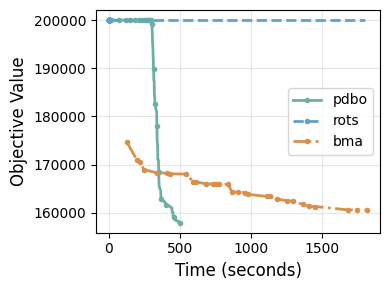

In [190]:
plot_improvements(file_dict)